In [1]:
# title import pkg
import warnings

warnings.filterwarnings("ignore")

import sys
import os


import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

#plt.style.use("ggplot")
sns.set_theme(style="ticks")
sns.set_context("paper")
sns.color_palette("husl", 8)
#plt.style.use('grayscale')

import re
from tqdm import tqdm
from IPython.display import clear_output

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.linear_model import (
    LogisticRegressionCV,
    LassoCV,
    Lasso,
    LogisticRegression,
)


sys.path.append(os.path.abspath("../"))
from dmldid.model_ro import DMLDiD_RO

from dmldid.simdata_genrater import generate_simdata_ro

In [2]:
def naive_did(
    df,
    y1_col,
    y0_col,
    d_col,
) -> np.float:
    _pivot = df.groupby(d_col)[[y0_col, y1_col]].mean()
    _pivot["diff"] = _pivot.diff(axis=1)[y1_col]
    
    return _pivot["diff"].diff().values[-1]

## Chang (2020) 's simulation data
- The following uses the author's R [code](https://github.com/NengChiehChang/Diff-in-Diff/blob/master/Figure%202/Lasso_N200_P100.R) as is to generate data


In [3]:
%load_ext rpy2.ipython

In [4]:
%%R 
#Data generating #Repeated outcomes
set.seed(666)
B=1000
N=200
p=100
s=5
X=array(rnorm(N*B*p,0,1),dim=c(B,N,p))
gamma=c(s:1,rep(0,(p-s)))/s

D=matrix(0,B,N)
z=matrix(0,B,N)
pr=matrix(0,B,N)

for (i in 1:B){
  z[i,] = X[i,,]%*%gamma        # linear combination 
  pr[i,] = 1/(1+exp(-z[i,]))         # P(D=1 given X) Probit
  D[i,] = rbinom(N,1,pr[i,]) 
}


beta1=gamma+0.5
beta2=gamma+1
theta=3

e1=matrix(rnorm(B*N,0,0.1),B,N)
e2=matrix(rnorm(B*N,0,0.1),B,N)
e3=matrix(rnorm(B*N,0,0.1),B,N)

Y00=matrix(0,B,N)
Y01=matrix(0,B,N)
Y11=matrix(0,B,N)

for (i in 1:B){
  
  Y00[i,]=X[i,,]%*%beta1+e1[i,]
  Y01[i,]=Y00[i,]+1+e2[i,]
  Y11[i,]=theta+Y01[i,]+e3[i,]
}

Y0=Y00
Y1=Y01*(1-D)+Y11*D

In [5]:
%R -o Y0
%R -o Y1
%R -o D
%R -o X

In [6]:
# pd.DataFrame({"Y0": Y0}, index=range(len(Y0)))
B = 1000
sim_df = {}
for i in range(B):
    _df = pd.DataFrame(
        {
            "Y0": Y0[i],
            "Y1": Y1[i],
            "D": D[i],
        }
    )
    _x = pd.DataFrame(X[i])
    _x = _x.add_prefix("x")
    _df = pd.concat([_df, _x], axis=1)

    sim_df[i] = _df
X_cols = _x.columns

In [7]:
sim_df[0]

,Y0,Y1,D,x0,x1,x2,x3,x4,x5,x6,...,x90,x91,x92,x93,x94,x95,x96,x97,x98,x99
0,4.194871,8.189595,1.0,0.753311,-0.742565,-0.216704,-1.437628,0.657002,-1.249259,0.456052,...,0.119928,0.534389,-0.203293,0.031390,0.188060,-0.469252,-0.674710,-0.344935,1.483094,-0.771318
1,-4.485210,-3.318985,0.0,0.119251,-0.746319,-1.143057,-0.154627,-0.910171,1.548606,-0.244934,...,0.172914,-0.360869,0.189739,-0.040830,-0.787919,-2.217366,1.009938,1.399078,-0.184318,-1.690952
2,4.081106,7.914536,1.0,0.540857,0.507727,-1.513591,-0.270136,-0.423558,-0.354318,-0.205049,...,1.209264,-0.157166,1.279642,-0.123755,0.628699,0.602482,-0.132661,2.463611,1.167446,0.751102
3,-5.783153,-4.924301,0.0,0.537794,-2.596542,-1.690638,1.522426,1.055078,-1.951810,-0.320155,...,0.512278,1.098436,-1.366625,0.707585,0.302395,0.540240,1.428050,0.035794,-1.224320,-0.737310
4,-4.126289,-0.093232,1.0,0.626794,0.136704,-0.565350,0.906605,1.148992,-0.150475,-0.206002,...,-1.013074,0.126897,-0.375286,-1.621005,0.430286,-1.112809,0.785893,0.017382,0.979593,-2.087417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-1.786388,2.217365,1.0,1.050801,0.269829,-0.865279,0.244173,0.877101,-0.467028,-0.917232,...,-2.251874,-0.441809,0.472536,0.357829,0.661119,-0.365128,-0.768667,0.866184,-1.780842,0.938400
196,10.702416,14.711109,1.0,0.744967,0.692592,-0.740005,1.380150,-1.573859,-1.243743,-0.405303,...,0.278331,-0.144812,1.554721,-0.230995,0.753165,1.418632,-0.316421,-0.528221,0.970925,-0.173620
197,8.266176,12.261925,1.0,0.710132,1.619895,1.306057,1.529951,-1.909356,1.265497,1.317186,...,0.046463,1.995609,-2.130283,0.751899,-0.850029,0.327437,-0.043062,-0.989929,-0.125928,0.182567
198,1.113038,2.100735,0.0,-1.510137,0.190121,2.203923,-0.275049,0.334102,-0.297491,0.428730,...,-1.310230,1.181245,-1.095886,-1.390148,0.934122,1.108631,0.852482,1.493936,0.096214,0.368974


In [8]:
y1_col = "Y1"
y0_col = "Y0"
d_col = "D"

naive_did_result = []
dmldid_lasso_result = []
abadie_lasso_result = []
dmldid_lgbm_result = []
abadie_lgbm_result = []
sim_cnt = 1000

for i in range(sim_cnt):
    df = sim_df[i]
    X_cols = [col for col in df.columns if "x" in col]

    naive_did_result.append(
        naive_did(
            df,
            y1_col=y1_col,
            y0_col=y0_col,
            d_col=d_col,
        )
    )
    linear_dmldid = DMLDiD_RO(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l1k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y1_col=y1_col,
        y0_col=y0_col,
        d_col=d_col,
        X_cols=X_cols,
        dmldid=False,
        base_random_seed=1,
    )
    abadie_lasso_result.append(linear_dmldid.att())

    linear_dmldid = DMLDiD_RO(
        d_model=LogisticRegressionCV(
            cv=5, random_state=123, penalty="l1", solver="saga"
        ),
        l1k_model=LassoCV(cv=5, random_state=123),
    )
    linear_dmldid.fit(
        df,
        y1_col=y1_col,
        y0_col=y0_col,
        d_col=d_col,
        X_cols=X_cols,
        dmldid=True,
        base_random_seed=1,
    )
    dmldid_lasso_result.append(linear_dmldid.att())


    clear_output(wait=True)
    print(f"{i} naive DiD: ", np.mean(naive_did_result))
    print(f"{i} Abadie SemiDiD(Lasso): ", np.mean(abadie_lasso_result))
    print(f"{i} DMLDiD(Lasso): ", np.mean(dmldid_lasso_result))


999 naive DiD:  2.9994439479346964
999 Abadie SemiDiD(Lasso):  3.3880668978116693
999 DMLDiD(Lasso):  2.997565262520265


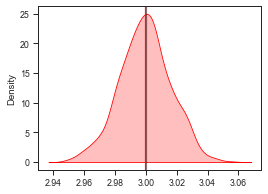

In [9]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(4,3))
#ax.hist(naive_did_result, bins=100, alpha=0.5)
sns.kdeplot(naive_did_result, shade=True, color="red", ax=ax)
#ax.set_xlim(2,4)
#ax.set_title("naive DiD result in Chang(2020)'s simulation data")
ax.axvline(x=3, alpha=0.5, color = "black")
ax.axvline(x=np.mean(naive_did_result),color="red", alpha=0.9)
fig.savefig("../fig/appendix_naive_did_original_sim.png")
plt.show()

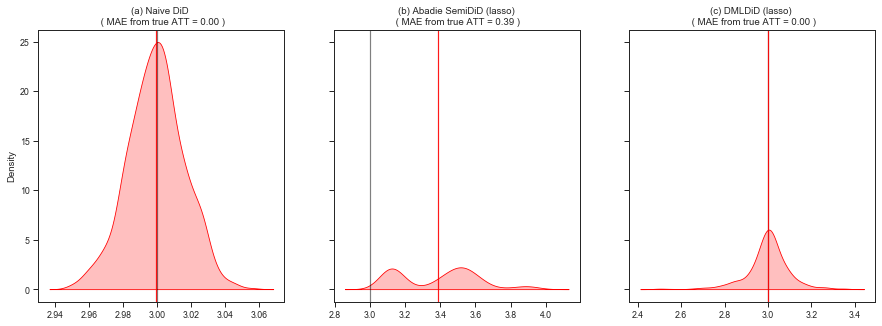

In [10]:
_label = [
    f"(a) Naive DiD \n ( MAE from true ATT = {np.abs(3-np.mean(naive_did_result)):.2f} )",
    f"(b) Abadie SemiDiD (lasso)\n ( MAE from true ATT = {np.abs(3-np.mean(abadie_lasso_result)):.2f} )",
    f"(c) DMLDiD (lasso) \n ( MAE from true ATT = {np.abs(3-np.mean( dmldid_lasso_result)):.2f} )",
]
result_df = pd.DataFrame(
    {
        "naive_did": naive_did_result,
        "abadie_lasso_result": abadie_lasso_result,
        "dmldid_lasso_result": dmldid_lasso_result
    }
)

fig, ax = plt.subplots(1, 3, sharex="col", sharey="row", figsize=(15, 5))
ax = ax.ravel()
for i, _col in enumerate(result_df.columns):
    sns.kdeplot(result_df[_col], shade=True, color="red", ax=ax[i])
    # ax[i].hist(result_df[_col], bins=50,color="red",alpha=0.5)
    #ax[i].set_xlim(-5,12.5)

    ax[i].set_title(_label[i])
    ax[i].axvline(x=3, alpha=0.5, color="black")
    ax[i].axvline(x=result_df[_col].mean(), color="red", alpha=0.9)
    ax[i].set_xlabel("")

fig.savefig("../fig/appendix_ro_lasso_original_sim.png", dpi=300)
plt.show()

In [11]:
result_df.to_csv("../sim_results/ro_simdata_chang.csv", index=False)

In [20]:
print("Done")

Done
